In [1]:
import numpy as np
import matplotlib as mpl
mpl.rcParams['figure.dpi']= 100
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import axes3d    
import matplotlib.dates as mdates
import matplotlib.gridspec as gs
import pandas as pd
import seaborn as sns

In [2]:
data = pd.read_csv('Task 3 and 4_Loan_Data.csv')

In [3]:
data

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0
...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0


In [4]:
FICOs = data[['fico_score','default']]

In [5]:
FICOs

,fico_score,default
0,605,0
1,572,1
2,602,0
3,612,0
4,631,0
...,...,...
9995,697,0
9996,615,0
9997,596,0
9998,647,0


# In this task, we will take the log-likelihood function approach

## First, let's see what this function looks like as a function of k and n

In [6]:
def log_likelihood(k, n, cushion=1e-12):
    if n == 0:
        return -np.inf
    p = k/n
    #prevent divergences
    p = np.clip(p, cushion, 1 - cushion)

    return k*np.log(p) + (n - k)*np.log(1-p)


### Slices

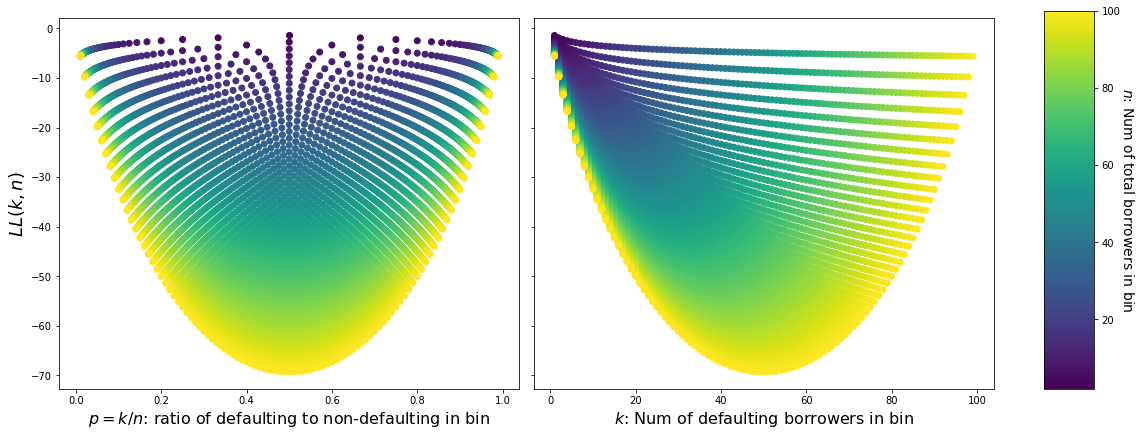

In [7]:
n = np.arange(2,101)
Ks = [np.arange(1,n_i) for n_i in n]
fig, (ax0,ax) = plt.subplots(1,2,figsize=(14,6),sharey=True)
cmap = cm.viridis
norm = mcolors.Normalize(vmin=2, vmax=100)
for i,k in enumerate(Ks):
    LL = log_likelihood(k,n[i])
    p = k/n[i]
    ax0.scatter(p,LL,c=[n[i]]*len(LL),cmap=cmap,norm=norm)
    im = ax.scatter(k,LL,c=[n[i]]*len(LL),cmap=cmap,norm=norm)
ax.set_xlabel(r'$k$: Num of defaulting borrowers in bin',fontsize=16);
ax0.set_xlabel(r'$p = k/n$: ratio of defaulting to non-defaulting in bin',fontsize=16);
ax0.set_ylabel('$LL(k,n)$',fontsize=18);
fig.tight_layout()
cax = fig.add_axes([ax.get_position().x1+0.05, ax.get_position().y0,0.05, ax.get_position().y1-0.1])
fig.colorbar(im, cax=cax, orientation='vertical')
cax.set_ylabel(r'$n$: Num of total borrowers in bin',fontsize=14,rotation=270, labelpad=15);

### Some key takeaways:   
- In general, for a bin containing a small sample size (small $n$), the log-likelihood function takes less penalty. This is due to the second term that comes with the factor of $(n-k)$.
- In general, the log-likelihood function takes the most penalties when there is an even split between defaulters and non-defaulters in a bin and takes the least penalties when $p \sim 0$ or $\sim 1$. This makes sense since a binning that is split defaulters from non-defaulters more definitively is a better binning system.

## Now, lets look at the data

Default points and no default points sit right on top of eachother, so we'll do two separate plots.

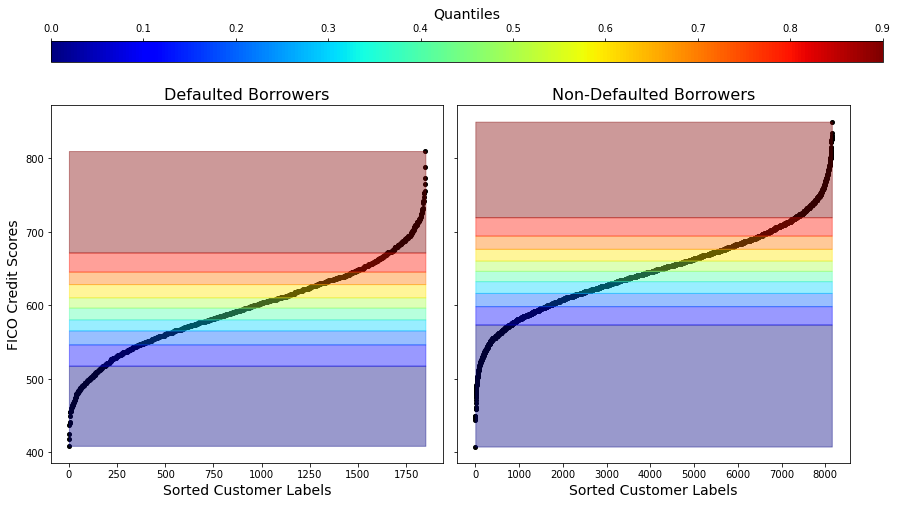

In [8]:
scores = FICOs['fico_score']
defs = FICOs['default']
scoresD = scores[defs==1]
scoresND = scores[defs==0]
XD = range(len(scoresD))
XND = range(len(scoresND))

fig,(axD,axND) = plt.subplots(1,2,figsize=(12,6),sharey=True)
axD.scatter(XD,scoresD.sort_values(),c='k',s=16);
axND.scatter(XND,scoresND.sort_values(),c='k',s=16);

quantiles = np.arange(0,11)/10.
qD = np.quantile(scoresD,quantiles)
qND = np.quantile(scoresND,quantiles)
cmap = cm.jet
norm = mcolors.Normalize(vmin=0., vmax=0.9)
for qi in range(1,qD.size):
    rgba = cmap(norm(quantiles[qi-1])) 
    axD.fill_between(XD,qD[qi-1],qD[qi],color=rgba,alpha=.4)
    axND.fill_between(XND,qND[qi-1],qND[qi],color=rgba,alpha=.4)
    
axD.set_xlabel('Sorted Customer Labels',fontsize=14);
axND.set_xlabel('Sorted Customer Labels',fontsize=14);
axD.set_ylabel('FICO Credit Scores', fontsize=14);

axD.set_title('Defaulted Borrowers',fontsize=16);
axND.set_title('Non-Defaulted Borrowers',fontsize=16);

fig.tight_layout()

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cax = fig.add_axes([axD.get_position().x0, axD.get_position().y1+0.1,
                    axND.get_position().x1-0.025, 0.05])
fig.colorbar(sm, cax=cax, orientation='horizontal')
cax.xaxis.set_ticks_position('top')
cax.set_title('Quantiles',fontsize=14);


For the histogram, we stack the data on top of eachother to see how they compare. Notice a few bins a bit greater than fico_score $=500$ where defaults are roughly split between did and didn't. That is likely the hardest area to bin properly. 

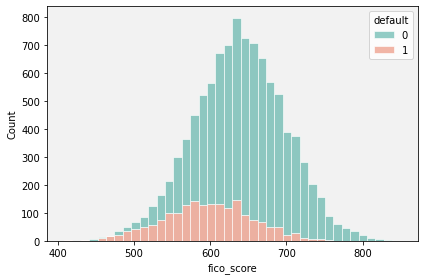

In [9]:
palette = {0: "#2a9d8f", 1: "#e76f51"}
ax = sns.histplot(
    data=FICOs, x="fico_score", hue="default",
    multiple="stack", bins=40,
    alpha=0.5,
    edgecolor="white", linewidth=0.6, palette=palette
)
ax.set_facecolor("#f2f2f2")
plt.tight_layout()

# Binning

Now, we will instead focus on working with the entire batch of data. Our strategy will conceptually be something like a binary search in quantile space.   
- First, we will divide the entire group into $10$ quantiles, as above in the scatter plots; these will be our first $10$ bins.
- Then, for each bin we will subdivide into $2$ quantiles (above and below the median) and check to see if the log-likelihood changes greater than some threshold.
- If it does, we continue breaking the resulting bins again into $2$ quantiles until the log-likelihood does not change very much. This process is repeated until all bins are off the stack.

In [10]:
def Create_Binning(ficos, LL=log_likelihood, dMIN=10, eps=1e-6):
    '''
        Function which takes in pandas DataFrame, ficos, with the columns: 'fico_score','default'.
        Also takes in which function you would like to optimize, log_likelihood by default.
        
        This function works to maximize the likelihood function as paramterized by the number of bins,
        giving the total number of borrowers in each bin, n, and the number of defaulted borrowers, k.
        
        The maximization process subdivides bins until the likelihood function imporvement is by less
        than the paramter eps. Every bin should satisfy that dMIN is the minimum number of defaults
        in a bin, default min is 10.

    '''
    
    scores = ficos[['fico_score','default']].to_numpy()
    # The list we will eventually return: BINS,
    # We will keep updating it by finding the optimal split points within the bins
    # But it starts off as one big bin
    BINS = [scores]
    # And we initialize the our quantity to minimize
    n = scores.shape[0]
    k = np.count_nonzero(scores[:,1])
    F = LL(k,n)
    Delta = np.inf
    # For stabiliy, minimum n in a bin is set dMIN and PR
    PR = k/n
    nMIN = max(int(np.ceil(dMIN / PR)), int(np.ceil(dMIN / (1 - PR))))
    
    # Now for the workhorse loop, run it until our objective stops increasing
    while Delta > eps:
####BEGIN outer while loop
        newBins = []
        cumulDelta = 0
        for B in BINS:
########BEGIN BIN loop
            # We should make sure that it's at least possible in one case to have large enogh bins
            if B.shape[0] < 2*nMIN:
                newBins.append(B)
                continue
            # For deciding and storing best bin
            best_bins = None
            bestF = F
            base = LL(np.count_nonzero(B[:,1]),B.shape[0])
            # Now, we loop through possible binning values
            for S in set(B[:,0]):
############BEGIN intra-bin search
                bin_mask = B[:,0] <= S
                binL, binH = B[bin_mask], B[~bin_mask]
                nL, nH = binL.shape[0], binH.shape[0]
                kL, kH = np.count_nonzero(binL[:,1]), np.count_nonzero(binH[:,1])
                # Bins population should pass minimum constraints (somewhat arbitrary)
                # Else continue on to try next bin
                if nL < nMIN or nH < nMIN or kL < dMIN or kH < dMIN or (nL-kL) < dMIN or (nH - kH) < dMIN:
                    continue
                candF = F - base + LL(kL, nL) + LL(kH, nH)
                if candF > bestF + eps*eps:
                    bestF = candF
                    best_bins = [binL, binH]
############END intra-bin search          
            # For a given bin, after looping through all possible _new_ splittings and having decided the
            # best one, we now add the new bins, unless no bin was good enough.
            # Then, we calculate the new Delta and reset the objective, F.
            if best_bins is None:
                newBins.append(B)
            else:
                newBins.extend(best_bins)
                cumulDelta += bestF - F
                F = bestF
########END BIN loop
        
        # Copy over updated bins after each update attempt in the BINS list
        BINS = newBins.copy()
        # cumulDelta is only less than threshold when it remains as 0 after looping through all bins.
        # In that only case will the loop terminate
        Delta = cumulDelta
        
    return BINS

### create bins and view new data bins

In [11]:
bins = Create_Binning(FICOs, LL=log_likelihood, dMIN=50)

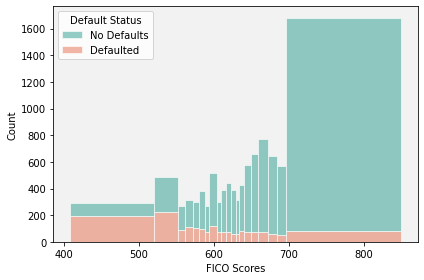

In [12]:
left_edge  = min(b[:,0].min() for b in bins)
right_edges = [b[:,0].max() for b in bins]
bin_edges = np.r_[left_edge, right_edges]  

BINS = pd.DataFrame(np.concatenate(bins),columns=['FICO Scores','Default Status'])
BINS['Default Status'] = BINS['Default Status'].map({0:'No Defaults', 1:'Defaulted'})

palette = {'No Defaults': "#2a9d8f", 'Defaulted': "#e76f51"}
ax = sns.histplot( 
    data=BINS, x='FICO Scores', hue='Default Status',
    multiple="stack", bins=bin_edges,
    alpha=0.5,
    edgecolor="white", linewidth=0.6, palette=palette
)
ax.set_facecolor("#f2f2f2") 
plt.tight_layout()

Intuitively, this makes sense. The bins at the edes are quite large since those bins are good indicators of defaulting or not and the bins need to be larger to contain about the same amount of elements as the bins in the middle. The bins in the middle are quite thin because it is where most scores lie. In this region, the FICO scores themselves are not such a useful indicator of whether or not someone will default, as can be seen by the comparatively constant ratio of default to total elements in the middle vs the extremes towards the edge. This also explains why there are some noisy bins in the middle in terms of their size variation; the middle scores give less information about default probabilities.   
   
This binning is close to ideal for Charlie's classification problem. However, we have more bins than we would probably want to have and need a good way to deal with the noisy middle. Luckily, we have a lot of data and can up the constraint on how many elements should be included in each bin.

In [13]:
bins = Create_Binning(FICOs, LL=log_likelihood, dMIN=175)

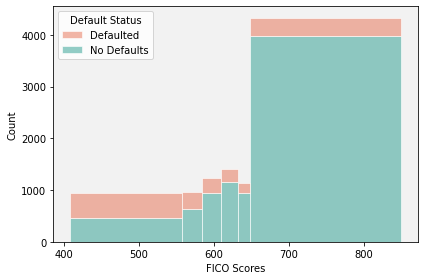

In [14]:
left_edge  = min(b[:,0].min() for b in bins)
right_edges = [b[:,0].max() for b in bins]
bin_edges = np.r_[left_edge, right_edges]  

BINS = pd.DataFrame(np.concatenate(bins),columns=['FICO Scores','Default Status'])
BINS['Default Status'] = BINS['Default Status'].map({0:'No Defaults', 1:'Defaulted'})

palette = {'No Defaults': "#2a9d8f", 'Defaulted': "#e76f51"}
ax = sns.histplot( 
    data=BINS, x='FICO Scores', hue='Default Status',
    multiple="stack", bins=bin_edges,
    alpha=0.5,
    edgecolor="white", linewidth=0.6, palette=palette
)
ax.set_facecolor("#f2f2f2") 
plt.tight_layout()

# So the final rating system is given by these bins and is the following:

- $5$: 408 - 558
- $4$: 559 - 585
- $3$: 586 - 610
- $2$: 611 - 632
- $1$: 633 - 649
- $0$: 650 - 850